### Belastingen uit RWS waterwebservices

In [29]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from toolbox_continu_inzicht import Config

Lees de configuratie in:

Dit leest een configuratie bestand `belasting_rws_config.yaml` in. 
```yaml
GlobalVariables:
    rootdir: "data_sets"
    moments: [ -24, 0, 24, 48 ]

    LoadsWaterwebservicesRWS:
        parameters: [ 'WATHTE' ]

DataAdapter:
    default_options:
        csv:
            sep: ","
    BelastingLocaties:
        type: csv
        path: "belastingen_rws.csv"
    Waterstanden_lokaal:
        type: csv
        path: "hidden_waterstanden.csv"
        sep: ";"
...

```

In [30]:
data_sets_path = Path.cwd() / "data_sets"
config = Config(config_path=data_sets_path / "belasting_rws_config.yaml")
config.lees_config()

Zet de data adapter klaar en geef deze de configuratie mee 

In [31]:
from toolbox_continu_inzicht import DataAdapter

data_adapter = DataAdapter(config=config)

Run de module met CSV

In [32]:
from toolbox_continu_inzicht.loads import LoadsWaterwebservicesRWS

RWS_webservice = LoadsWaterwebservicesRWS(data_adapter=data_adapter)

In [33]:
RWS_webservice.run(input="BelastingLocaties", output="Waterstanden_lokaal")

In [34]:
RWS_webservice.df_in

,measurement_location_id,measurement_location_code_name
measurement_location_code,,
857,278,moerdijk
1319,1,hoekvanholland


In [35]:
df_out = RWS_webservice.df_out
df_out

,measurement_location_id,measurement_location_code,measurement_location_description,parameter_id,parameter_code,date_time,unit,value,value_type
0,278,moerdijk,Moerdijk,4724,WATHTE,2026-05-25 14:00:00+01:00,cm,39.0,meting
1,278,moerdijk,Moerdijk,4724,WATHTE,2026-05-25 14:10:00+01:00,cm,40.0,meting
2,278,moerdijk,Moerdijk,4724,WATHTE,2026-05-25 14:20:00+01:00,cm,40.0,meting
3,278,moerdijk,Moerdijk,4724,WATHTE,2026-05-25 14:30:00+01:00,cm,41.0,meting
4,278,moerdijk,Moerdijk,4724,WATHTE,2026-05-25 14:40:00+01:00,cm,42.0,meting
...,...,...,...,...,...,...,...,...,...
563,1,hoekvanholland,Hoek van Holland,4724,WATHTE,2026-05-26 13:30:00+01:00,cm,68.0,meting
564,1,hoekvanholland,Hoek van Holland,4724,WATHTE,2026-05-26 13:40:00+01:00,cm,62.0,meting
565,1,hoekvanholland,Hoek van Holland,4724,WATHTE,2026-05-26 13:50:00+01:00,cm,57.0,meting
566,1,hoekvanholland,Hoek van Holland,4724,WATHTE,2026-05-26 14:00:00+01:00,cm,50.0,meting


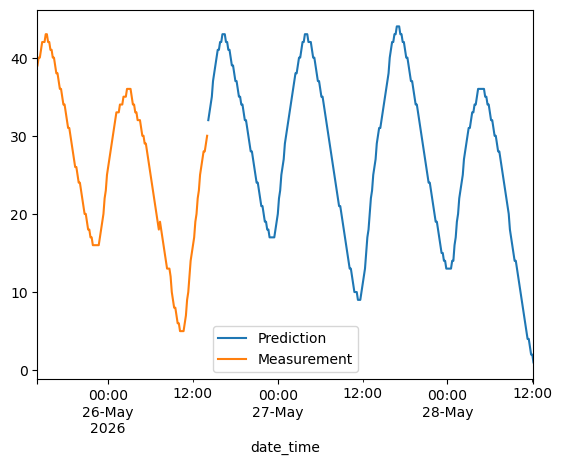

In [36]:
# split de dataframe in tweeën & process
values_nan = df_out[df_out["value"] == -999].index
for val in values_nan:
    df_out.loc[val, "value"] = np.nan
df_out.sort_index()
df_plot = df_out.set_index(df_out["date_time"])
df_plot = df_plot[
    df_plot["measurement_location_code"]
    == df_out["measurement_location_code"].unique()[0]
]
measurement_index = df_plot["value_type"] == "verwachting"
df_plot_measurements = df_plot[measurement_index][["value"]]
df_plot_forecast = df_plot[~measurement_index][["value"]]

fig, ax = plt.subplots()
df_plot_measurements.plot(color="C0", ax=ax)
df_plot_forecast.plot(color="C1", ax=ax)
ax.legend(["Prediction", "Measurement"]);

```yaml

    Waterstanden_database:
        type: ci_postgresql_measuringstation_to_data
        database: "continuinzicht"
        schema: "continuinzicht_demo_realtime"

```

In [37]:
from toolbox_continu_inzicht.helpers import calculation_start

start, end = calculation_start(
    data_adapter=data_adapter, output="calculation_start_config", calc_time=None
)
print(f"{start} - {end}")

2026-05-25 13:00:00+00:00 - 2026-05-28 13:00:00+00:00


In [38]:
# De adapter 'ci_postgresql_calc_status' geeft de huidige rekenstatus en eventuele ui aanpassingen terug
df_in = data_adapter.input("in_ci_status")

# controleer het resultaat op is_calculating = True
is_calculating = df_in[df_in["is_calculating"]]
if len(is_calculating) > 0:
    print("Er wordt al gerekend, toch doorgaan?")
    raise UserWarning("Er wordt al gerekend!")
else:
    print("Er wordt niet gerekend")

Er wordt niet gerekend


In [39]:
RWS_webservice.run(input="BelastingLocaties", output="Waterstanden_database")

In [40]:
from toolbox_continu_inzicht.loads import LoadsToMoments

load_moments = LoadsToMoments(data_adapter=data_adapter)
load_moments.run(input="in_measuringstations_table", output="df_moment_waterstanden")


In [41]:
df_moments = load_moments.df_out.reset_index(drop=False)
df_moments["date_time"] = df_moments["date_time"].astype(object)
# dataframe moments toevoegen aan adapter
data_adapter.set_dataframe_adapter("df_moment_waterstanden", df_moments)
df_moment_waterstanden = data_adapter.input("df_moment_waterstanden")

In [42]:
condition = data_adapter.input("in_measuringstation_conditions_table")

In [43]:
data_adapter.input("df_moment_waterstanden")

,date_time,measurement_location_id,measurement_location_code,measurement_location_description,parameter_id,parameter_code,parameter_description,unit,value,value_type,hours
0,2026-05-25 13:00:00+00:00,1,hoekvanholland,Hoek van Holland,1,H10,Gemeten waterstand,m+NAP,0.02,meting,-24
1,2026-05-25 13:00:00+00:00,278,moerdijk,Moerdijk,1,H10,Gemeten waterstand,m+NAP,0.39,meting,-24
2,2026-05-26 13:00:00+00:00,1,hoekvanholland,Hoek van Holland,1,H10,Gemeten waterstand,m+NAP,0.50,meting,0
3,2026-05-26 13:00:00+00:00,278,moerdijk,Moerdijk,1,H10,Gemeten waterstand,m+NAP,0.30,meting,0
4,2026-05-27 13:00:00+00:00,278,moerdijk,Moerdijk,2,H10V,Voorspelde waterstand,m+NAP,0.29,verwacht,24
5,2026-05-26 13:00:00+00:00,278,moerdijk,Moerdijk,1,H10,Gemeten waterstand,m+NAP,0.30,meting,48


In [44]:
from toolbox_continu_inzicht.loads import LoadsClassify

loads_classify = LoadsClassify(data_adapter=data_adapter)
loads_classify.run(
    input=["in_measuringstation_conditions_table", "df_moment_waterstanden"],
    output="out_measuringstation_states_table",
)


In [45]:
from toolbox_continu_inzicht.helpers import calculation_end

calculation_end(data_adapter=data_adapter, output="calculation_end_config")